In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Use DejaVu Serif as an alternative to Times New Roman
rcParams['font.family'] = 'DejaVu Serif'
rcParams['font.size'] = 12
rcParams['axes.titlesize'] = 14
rcParams['axes.labelsize'] = 12
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['legend.fontsize'] = 10

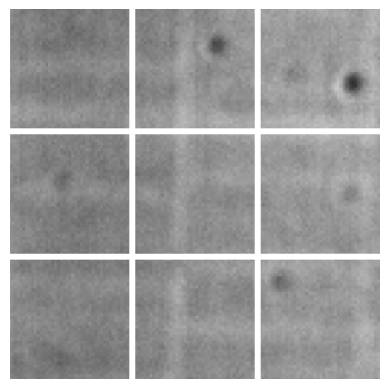

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def split_into_tokens(image, grid_size=(3, 3)):
    h, w, _ = image.shape
    token_h = h // grid_size[0]
    token_w = w // grid_size[1]
    
    tokens = []
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            y0 = i * token_h
            x0 = j * token_w
            token = image[y0:y0 + token_h, x0:x0 + token_w]
            tokens.append(token)
    return tokens

def plot_tokens(tokens, grid_size=(3, 3), spacing=5):
    token_h, token_w, _ = tokens[0].shape
    canvas_h = grid_size[0] * token_h + (grid_size[0] - 1) * spacing
    canvas_w = grid_size[1] * token_w + (grid_size[1] - 1) * spacing
    
    canvas = np.ones((canvas_h, canvas_w, 3), dtype=np.uint8) * 255  # white background

    for idx, token in enumerate(tokens):
        i = idx // grid_size[1]
        j = idx % grid_size[1]
        y = i * (token_h + spacing)
        x = j * (token_w + spacing)
        canvas[y:y + token_h, x:x + token_w] = token
    
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    # Save the figure with no borders or padding
    plt.savefig("tokens_plot_1.png", bbox_inches='tight', pad_inches=0)
    plt.show()

# Example usage:
image = cv2.imread('in.png')  # Replace with your image path
image = cv2.resize(image, (300, 300))  # Make divisible by 3x3
tokens = split_into_tokens(image)
plot_tokens(tokens)

In [13]:
import cv2
import numpy as np

def split_into_tokens(image, grid_size=(3, 3)):
    h, w, _ = image.shape
    token_h = h // grid_size[0]
    token_w = w // grid_size[1]
    
    tokens = []
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            y0 = i * token_h
            x0 = j * token_w
            token = image[y0:y0 + token_h, x0:x0 + token_w]
            tokens.append(token)
    return tokens

def save_flat_tokens_image(tokens, spacing=5, save_path="flat_tokens.jpg"):
    token_h, token_w, _ = tokens[0].shape
    num_tokens = len(tokens)

    # Width includes spacing between tokens but not around edges
    total_w = num_tokens * token_w + (num_tokens - 1) * spacing
    canvas = np.ones((token_h, total_w, 3), dtype=np.uint8) * 255  # white background

    for idx, token in enumerate(tokens):
        x = idx * (token_w + spacing)
        canvas[:, x:x + token_w] = token

    cv2.imwrite(save_path, canvas)


# Example usage
image = cv2.imread('in.png') # Replace with your image path
image = cv2.resize(image, (300, 300))  # Ensure divisible by 3
tokens = split_into_tokens(image)
save_flat_tokens_image(tokens, spacing=5, save_path="flat_token_strip.jpg")


In [14]:
results_yz = np.load("/home/zakarianarjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_Regression_zy_2025-08-05_12-03-23/results.npz")
loss_log = results_yz['loss_log']
predictions = results_yz['predictions']
gt_size_labels = results_yz['ground_truth_sizes']
size_labels = results_yz['size_labels']
import matplotlib.pyplot as plt
import numpy as np

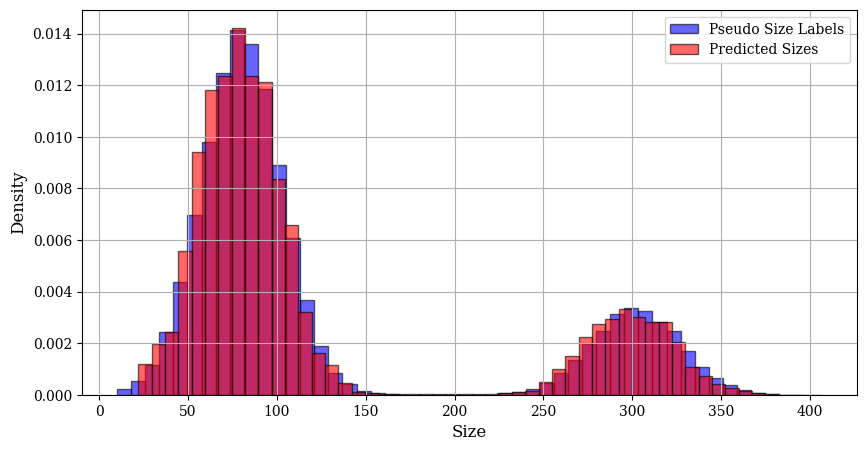

In [15]:
def plot_distribution(predictions, gt_size_labels, size_labels, save_path="size_distribution.png"):
    plt.figure(figsize=(10, 5))
    plt.hist(gt_size_labels, bins=50, alpha=0.6, label='Pseudo Size Labels', color='blue', edgecolor='black',density=True)
    plt.hist(predictions, bins=50, alpha=0.6, label='Predicted Sizes', color='red', edgecolor='black',density=True)
    plt.xlabel('Size')
    plt.ylabel('Density')
    plt.grid()
    plt.legend()
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()  
    plt.close()

plot_distribution(predictions, gt_size_labels, size_labels, save_path="size_distribution.png")

In [16]:
import h5py
import numpy as np
h5_paths = [
    "/scratch/narjis/iscat_data/brightfield_particles_x.hdf5",  
    "/scratch/narjis/iscat_data/brightfield_particles_y.hdf5",
    "/scratch/narjis/iscat_data/particles_3d_mf.hdf5"
]
sample_images = []  
for h5_path in h5_paths:
    # Take one sample image the first one
    with h5py.File(h5_path, "r") as h5_file:
        image = h5_file['data'][20]
        sample_images.append(image)
        print(image.shape)
volume_particle = (sample_images[-1] - np.min(sample_images[-1])) / (np.max(sample_images[-1]) - np.min(sample_images[-1]))

(16, 201)
(16, 201)
(201, 16, 16)


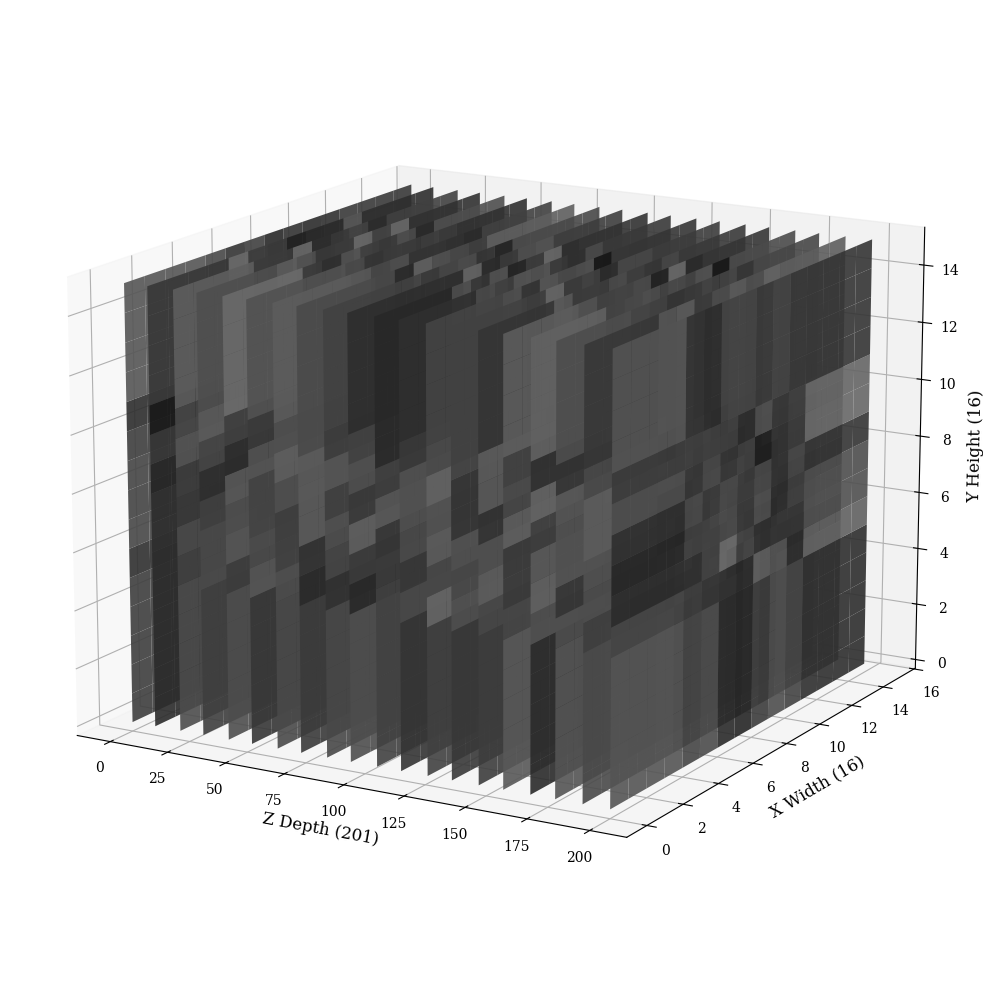

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_chunks(img, num_chunks=6):
    """
    Plot evenly spaced chunks from a 3D image as grayscale slices in 3D space.
    
    Args:
        img: numpy array of shape (201, 16, 16)
        num_chunks: number of chunks to plot (default: 6)
    
    Returns:
        chunk_indices: array of depth indices that were plotted
    """
    depth, height, width = img.shape
    
    # Calculate evenly spaced indices for chunks
    chunk_indices = np.linspace(0, depth - 1, num_chunks, dtype=int)
    
    # Create 3D plot
    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Create coordinate grids for plotting
    x = np.arange(width)
    y = np.arange(height)
    X, Y = np.meshgrid(x, y)
    
    # Plot each chunk
    for i, z_idx in enumerate(chunk_indices):
        # Get the 16x16 slice at depth z_idx
        slice_2d = img[z_idx, :, :]
        
        # Create X coordinate plane for this slice (horizontal progression)
        Z_plane = np.full_like(Y, z_idx, dtype=float)
        
        # Plot the surface rotated to be horizontal with grayscale colormap
        surf = ax.plot_surface(Z_plane, X, Y, facecolors=plt.cm.gray(slice_2d/slice_2d.max()), 
                              alpha=0.9, linewidth=0, antialiased=True)
    
    # Set labels and title
    ax.set_xlabel('Z Depth (201)')
    ax.set_ylabel('X Width (16)')
    ax.set_zlabel('Y Height (16)')
    
    # Set the viewing angle for better horizontal visualization
    ax.view_init(elev=15, azim=-60)
    
    # Adjust layout
    plt.tight_layout()
    #Save the figure
    plt.savefig("3d_chunks_plot.png")
    # Show the plot 
    plt.show()
plot_3d_chunks(volume_particle, num_chunks=20)

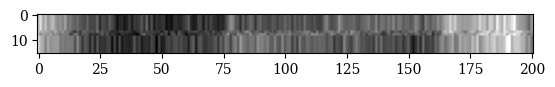

In [19]:
plt.imshow(sample_images[0], cmap='gray')

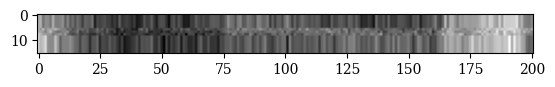

In [20]:
plt.imshow(sample_images[1], cmap='gray')